# Clustering
**This notebook applies an unsupervised clustering approach to patients with advanced urothelial cancer from the Flatiron Health database who received first-line pembrolizumab vs carboplatin-based chemotherapy. The goal is to identify distinct clinical subgroups that may reflect underlying differences in disease biology or host factors. These clusters will subsequently be evaluated using survival analysis to assess potential differential outcomes.**

**The workflow is divided into four main sections:**

**1. Feature Selection – Identify clinically and biologically relevant baseline variables to inform subgroup discovery.**

**2. Preprocessing – Handle missing data and standardize features to prepare the dataset for analysis.**

**3. Dimensionality Reduction – Apply Uniform Manifold Approximation and Projection (UMAP) to reduce the feature space while preserving meaningful structure.**

**4. Clustering – Use Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN) to identify patient subgroups in the lower-dimensional space.**

**5. Describing Clusters -- Clusters of sufficient size for survival analysis will be described.**

## Import data

In [1]:
import numpy as np
import pandas as pd

from flatiron_cleaner import DataProcessorUrothelial

In [2]:
dtype_map = pd.read_csv('../outputs/final_df_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
df = pd.read_csv('../outputs/final_df.csv', dtype = dtype_map)

In [3]:
df.shape

(6461, 149)

In [4]:
pembro_carbo_df = pd.read_csv('../outputs/full_cohort_carbo.csv')

In [5]:
pembro_carbo_df.head(3)

,PatientID,LineName,StartDate
0,F5AAF96C85477,Pembrolizumab,2021-07-08
1,F788831A66E9A,Pembrolizumab,2023-02-22
2,F6E944C1709E6,Pembrolizumab,2020-08-12


In [6]:
pembro_carbo_df.shape

(3712, 3)

In [7]:
processor = DataProcessorUrothelial()

# Process Enhanced_Mortality_V2.csv and use visit, telemedicine, biomarkers, oral, and progression data to determine censoring date 
mortality_df = processor.process_mortality(file_path = '../data/Enhanced_Mortality_V2.csv',
                                           index_date_df = pembro_carbo_df, 
                                           index_date_column = 'StartDate',
                                           visit_path = '../data/Visit.csv', 
                                           telemedicine_path = '../data/Telemedicine.csv', 
                                           biomarkers_path = '../data/Enhanced_AdvUrothelialBiomarkers.csv', 
                                           oral_path = '../data/Enhanced_AdvUrothelial_Orals.csv',
                                           progression_path = '../data/Enhanced_AdvUrothelial_Progression.csv',
                                           drop_dates = False)

2025-05-18 16:18:09,583 - INFO - Successfully read Enhanced_Mortality_V2.csv file with shape: (9040, 2) and unique PatientIDs: 9040
2025-05-18 16:18:09,592 - INFO - Successfully merged Enhanced_Mortality_V2.csv df with index_date_df resulting in shape: (3712, 3) and unique PatientIDs: 3712
2025-05-18 16:18:09,996 - INFO - The following columns ['last_visit_date', 'last_biomarker_date', 'last_oral_date', 'last_progression_date'] are used to calculate the last EHR date
2025-05-18 16:18:10,001 - INFO - Successfully processed Enhanced_Mortality_V2.csv file with final shape: (3712, 6) and unique PatientIDs: 3712. There are 0 out of 3712 patients with missing duration values


In [8]:
mortality_df = mortality_df.query('duration >= 0')

In [9]:
mortality_df.shape

(3706, 6)

In [10]:
mortality_df = pd.merge(mortality_df, pembro_carbo_df[['PatientID', 'LineName']], on = 'PatientID', how = 'left')

In [11]:
mortality_df.shape

(3706, 7)

In [12]:
ids = mortality_df.PatientID.to_list()

In [13]:
df = df.query('PatientID in @ids')

In [14]:
df.shape

(3706, 149)

## 1. Feature Selection
**The currently cleaned dataset contains about 150 features captured at the time of treatment initiation. We'll hand-select approximately 50 features based on clinical expertise, biological plausibility, and known prognostic or predictive value. This manual curation step serves as a form of informed feature reduction prior to applying unsupervised dimensionality reduction techniques and clustering algorithms. The goal is to improve signal-to-noise ratio and support downstream analysis of distinct phenotypic subgroups that may respond differently to first-line chemotherapy or immunotherapy.** 

In [15]:
df_raw = df.copy()

In [16]:
df = df.set_index('PatientID')

In [17]:
df = df[[
    'PrimarySite_lower',
    'SmokingStatus',
    'Surgery',
    'GroupStage_mod',
    'days_diagnosis_to_adv',
    'age',
    'PDL1_status',
    'FGFR_status',
    'ecog_index',
    'ecog_newly_gte2',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'hypotension',
    'tachycardia',
    'fevers',
    'hypoxemia',
    'platelet',
    'hemoglobin', 
    'wbc', 
    'creatinine', 
    'potassium', 
    'calcium', 
    'sodium', 
    'bicarbonate', 
    'total_bilirubin', 
    'alp', 
    'ast', 
    'albumin', 
    'wbc_max', 
    'creatinine_max', 
    'sodium_max',
    'total_bilirubin_max', 
    'alp_max', 
    'ast_max', 
    'platelet_min',
    'hemoglobin_min', 
    'wbc_min',
    'albumin_min', 
    'sodium_min', 
    'bicarbonate_min', 
    'potassium_min',
    'anticoagulant', 
    'opioid', 
    'antibiotic', 
    'diabetic_med', 
    'bone_therapy_agent', 
    'immunosuppressant', 
    'van_walraven_score',
    'lymph_met', 
    'thoracic_met', 
    'liver_met', 
    'bone_met',
    'other_gi_met', 
    'other_combined_met' 
]]

In [18]:
df.shape

(3706, 55)

## 2. Preprocessing
**In this section, we'll create a pipeline for handling missing data, one-hot-encoding categorical variables, and standardizing numerical values prior to applying dimensionality reduction and clustering algorithms.** 

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

In [20]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       1495
albumin                   566
total_bilirubin           537
albumin_min               520
ast                       519
alp                       517
calcium                   511
bicarbonate               506
total_bilirubin_max       491
sodium                    485
potassium                 484
ast_max                   474
alp_max                   472
bicarbonate_min           460
creatinine                444
sodium_max                442
sodium_min                442
potassium_min             441
creatinine_max            401
percent_change_weight     308
wbc                       224
platelet                  221
hemoglobin                221
wbc_max                   208
wbc_min                   208
hemoglobin_min            205
platelet_min              205
bmi_index                  63
weight_index               56
dtype: int64

In [21]:
df.dtypes[df.dtypes == 'category']

GroupStage_mod    category
PDL1_status       category
FGFR_status       category
ecog_index        category
dtype: object

In [22]:
numerical_cols = list(missing[missing > 0].index)  
categorical_cols = list(df.select_dtypes(include='category').columns)

In [23]:
# Passthrough columns (ie., 1/0 columns and numeric features without missingness, like age)
set(df.columns) - set(numerical_cols) - set(categorical_cols)

{'PrimarySite_lower',
 'SmokingStatus',
 'Surgery',
 'age',
 'antibiotic',
 'anticoagulant',
 'bone_met',
 'bone_therapy_agent',
 'days_diagnosis_to_adv',
 'diabetic_med',
 'ecog_newly_gte2',
 'fevers',
 'hypotension',
 'hypoxemia',
 'immunosuppressant',
 'liver_met',
 'lymph_met',
 'opioid',
 'other_combined_met',
 'other_gi_met',
 'tachycardia',
 'thoracic_met'}

In [24]:
# Define preprocessors
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)],
    remainder = 'passthrough'
)

# Fit and transform
X_preprocessed = preprocessor.fit_transform(df)

In [25]:
X_preprocessed.shape

(3706, 65)

## 3. Dimensionality Reduction
**UMAP will be used to further reduce the dimensions from 65 columns after one-hot-encoding categorical variables to 15.** 

In [26]:
import umap

In [27]:
# Instantiate UMAP
reducer = umap.UMAP(
    n_neighbors = 15,     # Controls local vs global structure
    min_dist = 0.1,       # Controls how tightly UMAP packs points together
    n_components = 15,  
    random_state = 42,
    n_jobs = 1
)

# Apply UMAP
X_umap = reducer.fit_transform(X_preprocessed)  

/Users/xavierorcutt/Dropbox/TrialRescue/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [28]:
X_umap.shape

(3706, 15)

## 4. Clustering
**HDBSCAN will now be used to identify clusters. To have sufficient power to detect a HR of 0.8, we need clusters with at least 800 deaths. For details on power calculation, see power_calc.ipynb.** 

In [29]:
import hdbscan

In [30]:
clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, prediction_data = True)
clusterer.fit(X_umap)

/Users/xavierorcutt/Dropbox/TrialRescue/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/xavierorcutt/Dropbox/TrialRescue/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN(min_cluster_size=100, prediction_data=True)

In [31]:
# Returns array of cluster assignment by patient
labels = clusterer.labels_

unique, counts = np.unique(labels, return_counts = True)
cluster_sizes = pd.DataFrame({'Cluster': unique, 'Size': counts})
cluster_sizes = cluster_sizes.sort_values(by = 'Size', ascending = False).reset_index(drop = True)
print(cluster_sizes)

   Cluster  Size
0        0  1531
1        5   822
2        4   665
3        1   307
4        3   204
5        2   177


In [32]:
df['cluster'] = labels

## 5. Describing Clusters
**Clusters 0 and 4, which are of sufficient size for survival analysis, will be described** 

In [33]:
df = df.reset_index()

In [34]:
df.shape

(3706, 57)

In [35]:
df = pd.merge(df, mortality_df[['PatientID', 'LineName', 'event', 'duration']], on = 'PatientID', how = 'left')

In [36]:
df.shape

(3706, 60)

In [37]:
# Percentage patients receiving checkpoint vs chemo by cluster
(
    df
    .groupby(['cluster', 'LineName'])
    .size()
    .unstack(fill_value=0)
    .div(df.groupby('cluster').size(), axis=0)
)

LineName,Pembrolizumab,carboplatin
cluster,,
0,0.293926,0.706074
1,0.397394,0.602606
2,0.440678,0.559322
3,0.416667,0.583333
4,0.517293,0.482707
5,0.492701,0.507299


In [38]:
# Count of deaths for checkpoint vs chemo by cluster
(
    df
    .groupby(['cluster', 'LineName'])['event']
    .sum()
    .unstack(fill_value=0)
    .astype(int)
)

LineName,Pembrolizumab,carboplatin
cluster,,
0,305,817
1,87,144
2,54,73
3,51,89
4,234,237
5,259,299


In [39]:
#Create a new column indicating if duration < 90 days
df['early_death'] = (df['duration'] < 90).astype(int)

# Group by cluster and treatment, and calculate percentage
result = (
    df
    .groupby(['cluster', 'LineName'])
    .agg(
        total_patients = ('duration', 'count'),
        early_deaths = ('early_death', 'sum')
    )
)

# Add a column for percentage early deaths
result['percent_early_deaths'] = (result['early_deaths'] / result['total_patients']) * 100

# Round for prettier display
result['percent_early_deaths'] = result['percent_early_deaths'].round(1)

result

total_patients  early_deaths  percent_early_deaths
cluster LineName                                                         
0       Pembrolizumab             450           164                  36.4
        carboplatin              1081           179                  16.6
1       Pembrolizumab             122            32                  26.2
        carboplatin               185            27                  14.6
2       Pembrolizumab              78            22                  28.2
        carboplatin                99            10                  10.1
3       Pembrolizumab              85            21                  24.7
        carboplatin               119            19                  16.0
4       Pembrolizumab             344           115                  33.4
        carboplatin               321            55                  17.1
5       Pembrolizumab             405            89                  22.0
        carboplatin               417            63                  15.1

In [40]:
cluster_df = df[['PatientID', 'cluster']]

In [41]:
cluster_df.to_csv('../outputs/cluster_pembro_carbo_df.csv', index = False)

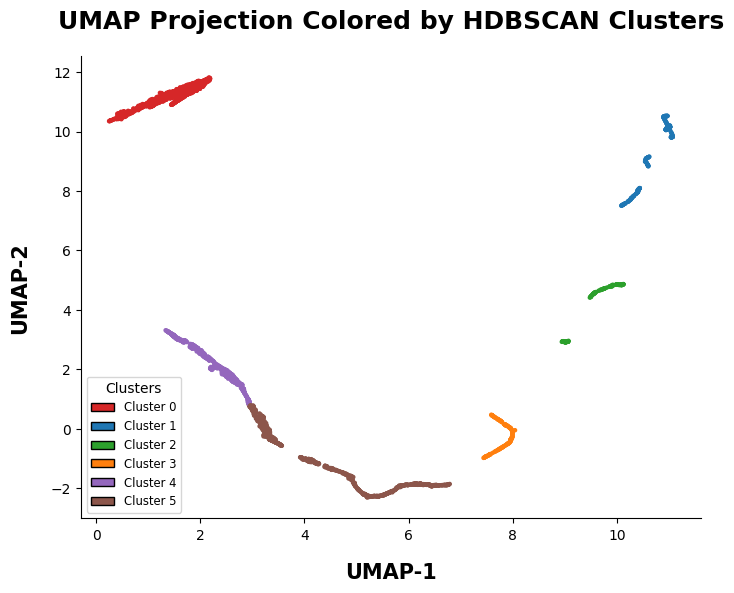

In [48]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define custom color palette
cluster_colors = {
    0: '#d62728', # red - highlight this
    1: '#1f77b4',  # blue
    2: '#2ca02c',  # green
    3: '#ff7f0e',  # orange
    4: '#9467bd',  # purple
    5: '#8c564b'   # brown
}

colors = [cluster_colors[label] for label in labels]

# Create legend handles
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=f'Cluster {label}' if label != -1 else 'Noise')
    for label, color in cluster_colors.items()
]

# Create plot
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=5)
plt.title('UMAP Projection Colored by HDBSCAN Clusters', size = 18, weight = 'bold',  pad = 20)
plt.xlabel('UMAP-1', size = 15, weight = 'bold', labelpad = 15)
plt.ylabel('UMAP-2', size = 15, weight = 'bold', labelpad = 15)
plt.legend(handles=legend_elements, title='Clusters', loc='best', fontsize='small')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/pembro_carbo_cluster.pdf', format = 'pdf', bbox_inches = 'tight')